In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data=pd.read_csv('/content/drive/MyDrive/Loan_default.csv')
pd.set_option('display.max_columns', None)
data.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [ ]:
rows, columns=data.shape
print(f'Dataset has {rows} rows and {columns} columns.')

Dataset has 255347 rows and 18 columns.


In [ ]:
rows, columns = data[data.duplicated()].shape
print("Dataset has no duplicates." if rows==0 else f'Dataset has {rows} duplicates')

Dataset has no duplicates.


In [ ]:
num, obj = 0,0
for feat in data.columns:
  if data[feat].dtypes=="O":
    obj +=1
  else:
    num +=1

print(f'Dataset has {num} numerical columns and {obj} categorical columns.')

Dataset has 10 numerical columns and 8 categorical columns.


In [ ]:
data_type=pd.DataFrame(data.dtypes, columns=['Data_type'])
missing_value=pd.DataFrame(data.isnull().mean() *100, columns=['Missing_percentage'])
data_concat=pd.concat([data_type, missing_value], axis=1)
data_concat

,Data_type,Missing_percentage
LoanID,object,0.0
Age,int64,0.0
Income,int64,0.0
LoanAmount,int64,0.0
CreditScore,int64,0.0
MonthsEmployed,int64,0.0
NumCreditLines,int64,0.0
InterestRate,float64,0.0
LoanTerm,int64,0.0
DTIRatio,float64,0.0


In [ ]:
data.drop(['LoanID'], axis=1, inplace=True)
data.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [ ]:
data.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age,255347.0,43.50,14.99,18.0,31.00,43.00,56.00,69.0
Income,255347.0,82499.30,38963.01,15000.0,48825.50,82466.00,116219.00,149999.0
LoanAmount,255347.0,127578.87,70840.71,5000.0,66156.00,127556.00,188985.00,249999.0
CreditScore,255347.0,574.26,158.90,300.0,437.00,574.00,712.00,849.0
MonthsEmployed,255347.0,59.54,34.64,0.0,30.00,60.00,90.00,119.0
NumCreditLines,255347.0,2.50,1.12,1.0,2.00,2.00,3.00,4.0
InterestRate,255347.0,13.49,6.64,2.0,7.77,13.46,19.25,25.0
LoanTerm,255347.0,36.03,16.97,12.0,24.00,36.00,48.00,60.0
DTIRatio,255347.0,0.50,0.23,0.1,0.30,0.50,0.70,0.9
Default,255347.0,0.12,0.32,0.0,0.00,0.00,0.00,1.0


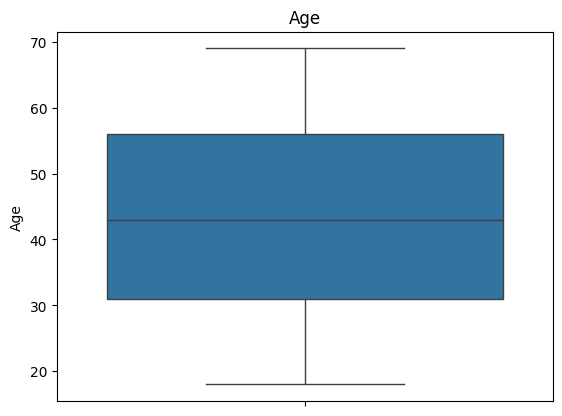

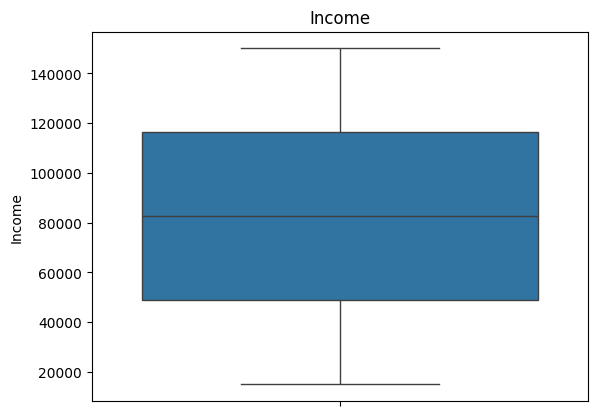

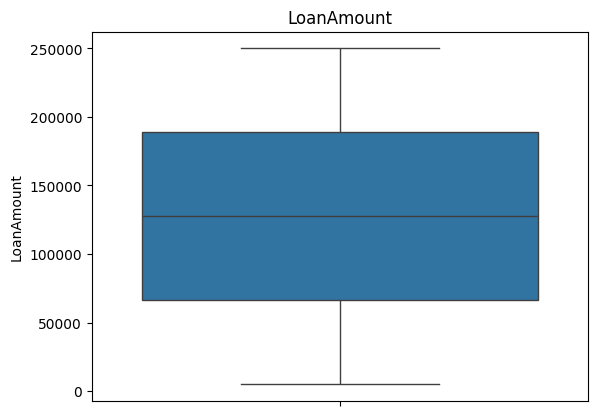

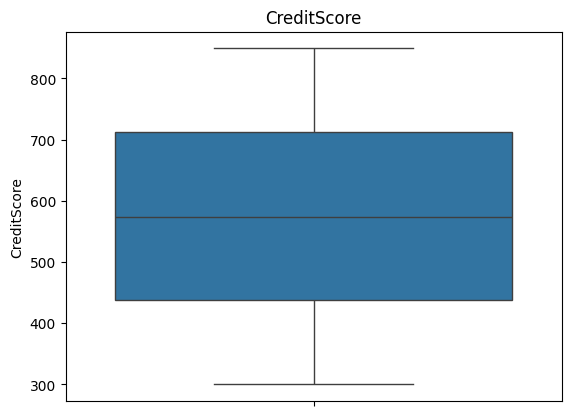

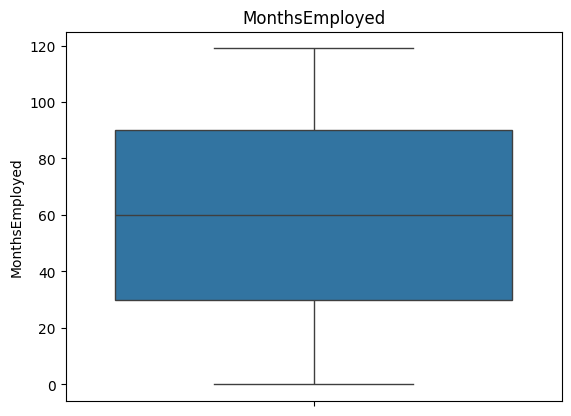

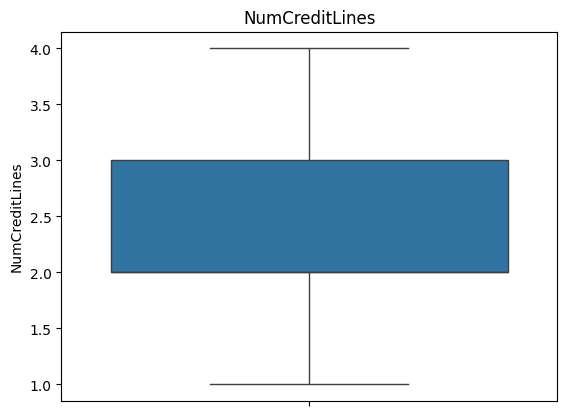

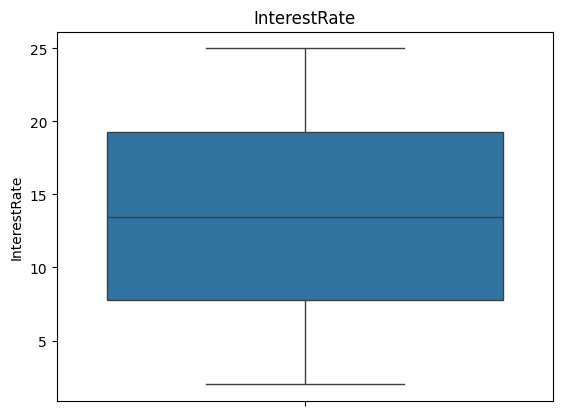

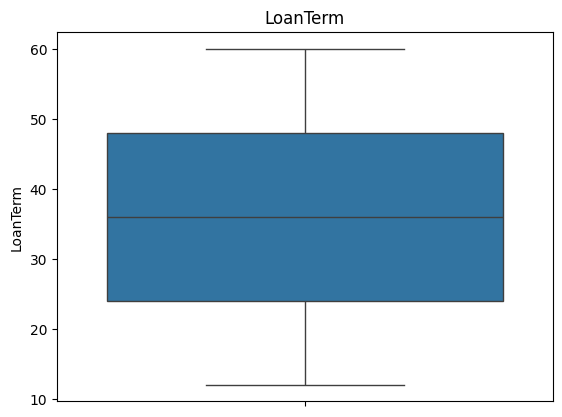

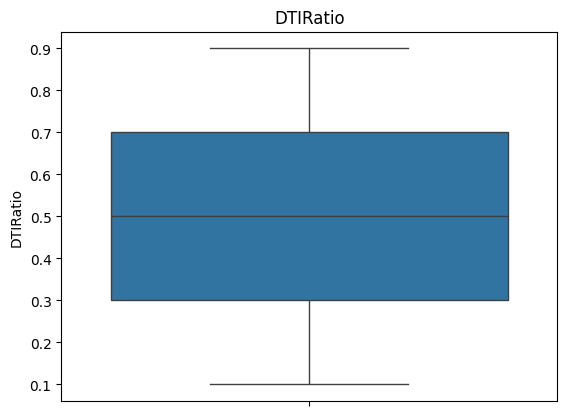

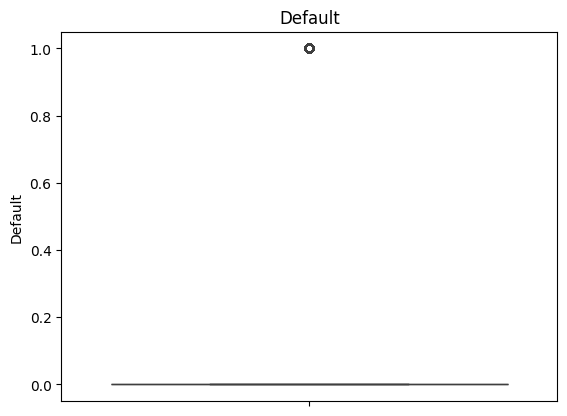

In [ ]:
def boxplots(col):
  sns.boxplot(data[col])
  plt.title(col)
  plt.show()

for i in list(data.select_dtypes(exclude='object').columns):
  boxplots(i)

In [ ]:
data.corr(numeric_only=True).round(2)

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
Age,1.00,-0.0,-0.00,-0.00,-0.0,-0.00,-0.00,0.0,-0.00,-0.17
Income,-0.00,1.0,-0.00,-0.00,0.0,-0.00,-0.00,-0.0,0.00,-0.10
LoanAmount,-0.00,-0.0,1.00,0.00,0.0,0.00,-0.00,0.0,0.00,0.09
CreditScore,-0.00,-0.0,0.00,1.00,0.0,0.00,0.00,0.0,-0.00,-0.03
MonthsEmployed,-0.00,0.0,0.00,0.00,1.0,0.00,0.00,-0.0,0.00,-0.10
NumCreditLines,-0.00,-0.0,0.00,0.00,0.0,1.00,-0.00,-0.0,-0.00,0.03
InterestRate,-0.00,-0.0,-0.00,0.00,0.0,-0.00,1.00,0.0,0.00,0.13
LoanTerm,0.00,-0.0,0.00,0.00,-0.0,-0.00,0.00,1.0,0.00,0.00
DTIRatio,-0.00,0.0,0.00,-0.00,0.0,-0.00,0.00,0.0,1.00,0.02
Default,-0.17,-0.1,0.09,-0.03,-0.1,0.03,0.13,0.0,0.02,1.00


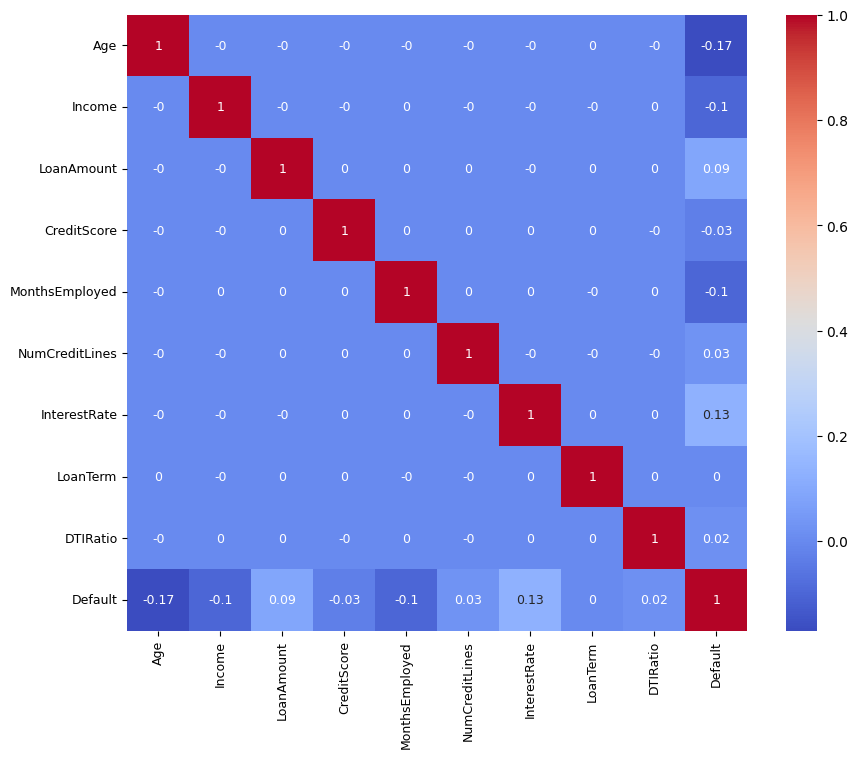

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(numeric_only=True).round(2), annot=True, annot_kws={"size": 9},cmap='coolwarm')
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.show()

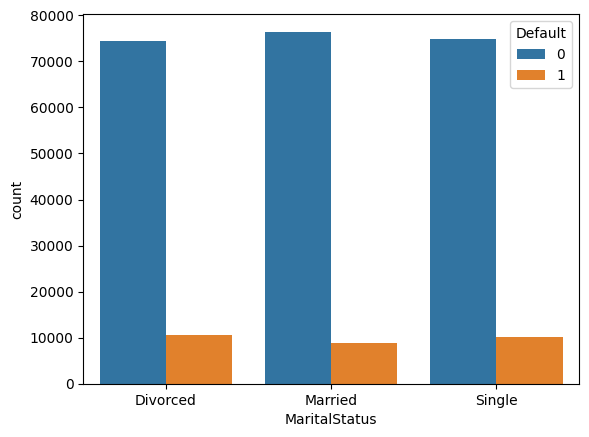

In [ ]:
sns.countplot(x='MaritalStatus', hue='Default', data=data)
plt.show()

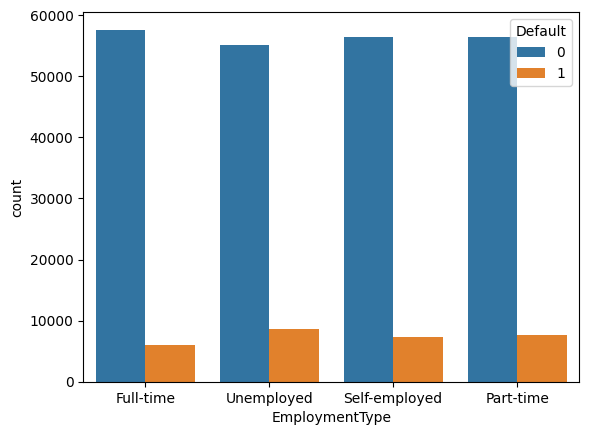

In [ ]:
sns.countplot(x='EmploymentType', hue='Default', data=data)
plt.show()

In [ ]:
pd.crosstab(data['Education'], data['Default'], normalize='index').round(2).astype(str) + '%'

Default,0,1
Education,,
Bachelor's,0.88%,0.12%
High School,0.87%,0.13%
Master's,0.89%,0.11%
PhD,0.89%,0.11%


In [ ]:
pd.crosstab(data['EmploymentType'], data['Default'], normalize='index').round(2).astype(str) + '%'

Default,0,1
EmploymentType,,
Full-time,0.91%,0.09%
Part-time,0.88%,0.12%
Self-employed,0.89%,0.11%
Unemployed,0.86%,0.14%


In [ ]:
data.columns

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education',
       'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents',
       'LoanPurpose', 'HasCoSigner', 'Default'],
      dtype='object')

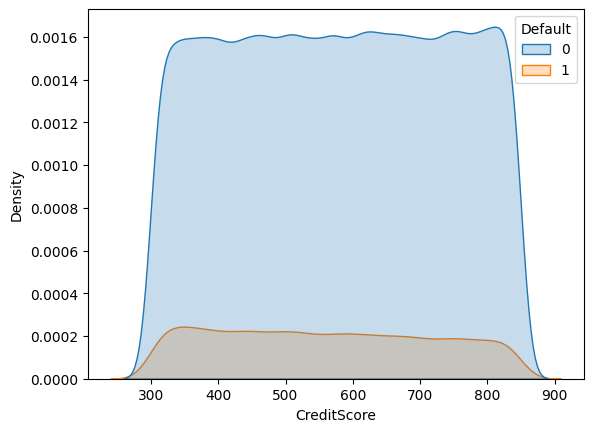

In [ ]:
sns.kdeplot(data=data, x='CreditScore', hue='Default', fill=True)
plt.show()

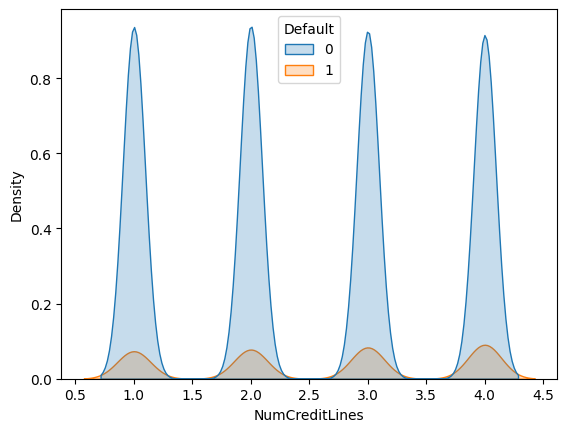

In [ ]:
sns.kdeplot(data=data, x='NumCreditLines', hue='Default', fill=True)
plt.show()

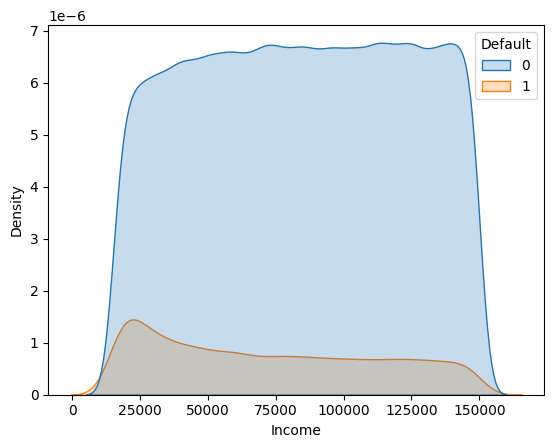

In [ ]:
sns.kdeplot(data=data, x='Income', hue='Default', fill=True)
plt.show()

In [ ]:
pd.crosstab(data['HasMortgage'], data['Default'], normalize='index').round(2).astype(str)+'%'

Default,0,1
HasMortgage,,
No,0.88%,0.12%
Yes,0.89%,0.11%


In [ ]:
pd.crosstab(data['LoanPurpose'], data['Default'], normalize='index').round(2).astype(str) + '%'

Default,0,1
LoanPurpose,,
Auto,0.88%,0.12%
Business,0.88%,0.12%
Education,0.88%,0.12%
Home,0.9%,0.1%
Other,0.88%,0.12%


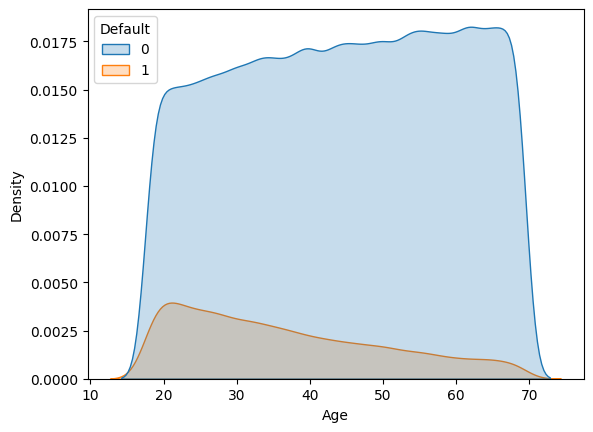

In [ ]:
sns.kdeplot(data=data, x='Age', hue='Default', fill=True)
plt.show()

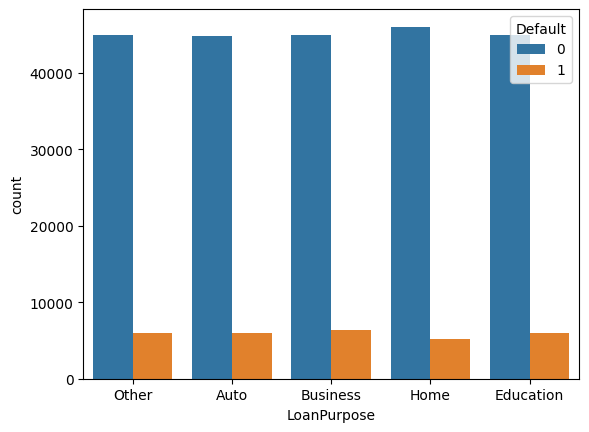

In [ ]:
sns.countplot(x='LoanPurpose', hue='Default', data=data)
plt.show()

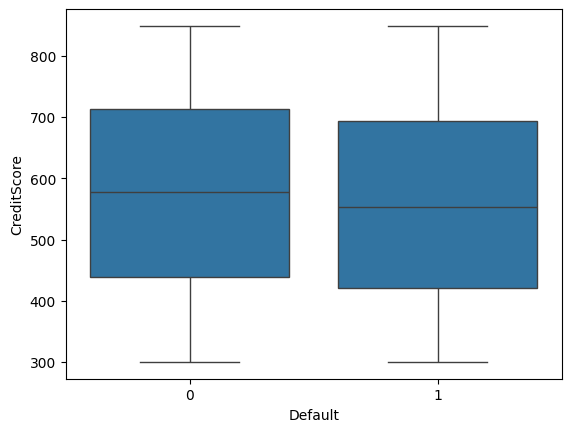

In [ ]:
sns.boxplot(x='Default', y='CreditScore', data=data)
plt.show()

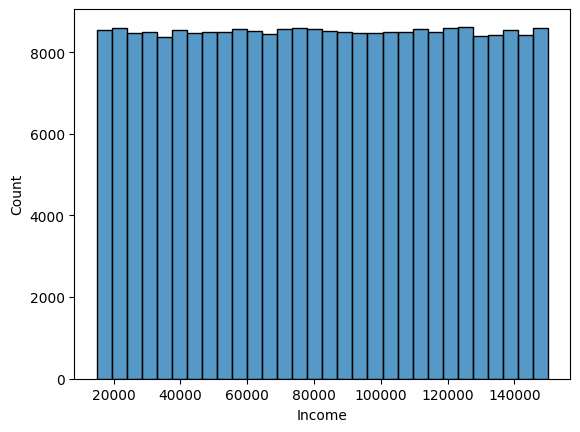

In [ ]:
sns.histplot(data['Income'], bins=30)
plt.show()

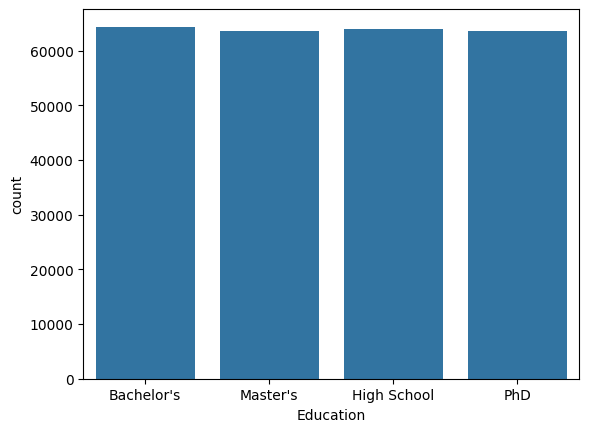

In [ ]:
sns.countplot(x='Education', data=data)
plt.show()

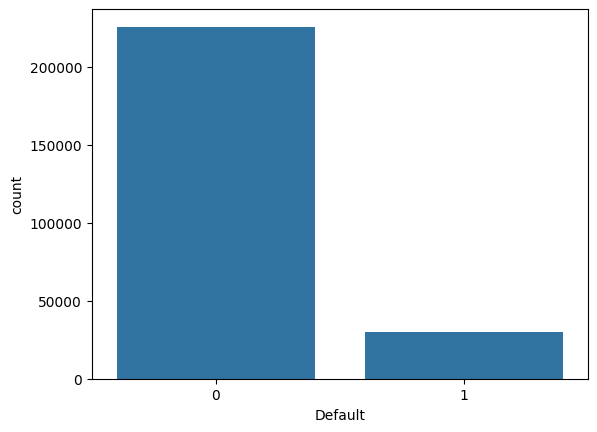

In [ ]:
sns.countplot(x='Default', data=data)
plt.show()

In [ ]:
bins = [300, 500, 650, 800, 900]
labels = ['Poor', 'Average', 'Good', 'Excellent']

data['Score_Bin'] = pd.cut(data['CreditScore'], bins=bins, labels=labels)

In [ ]:
pd.crosstab(data['Score_Bin'], data['Default'], normalize='index').round(2).astype(str) + '%'

Default,0,1
Score_Bin,,
Poor,0.87%,0.13%
Average,0.88%,0.12%
Good,0.89%,0.11%
Excellent,0.9%,0.1%


In [ ]:
bins = [300, 500, 700, 900]
data['Score_Bin'] = pd.cut(data['CreditScore'], bins=bins)

In [ ]:
ct=pd.crosstab(data['Score_Bin'], data['Default'], normalize='index').round(2).astype(str) + '%'
ct.index=ct.index.astype(str).str.replace(',','-')
print(ct)

Default         0      1
Score_Bin               
(300- 500]  0.87%  0.13%
(500- 700]  0.89%  0.11%
(700- 900]   0.9%   0.1%


In [ ]:
data['Income'].min()

15000

In [ ]:
data['Income'].max()

149999

In [ ]:
bins=[15000, 35000, 75000, 120000, 150000]
data['Income_Bin']=pd.cut(data['Income'], bins=bins)

In [ ]:
ct=pd.crosstab(data['Income_Bin'], data['Default'], normalize='index').round(2)
ct.index=ct.index.astype(str).str.replace(',','-')
print(ct)

Default              0     1
Income_Bin                  
(15000- 35000]    0.80  0.20
(35000- 75000]    0.88  0.12
(75000- 120000]   0.90  0.10
(120000- 150000]  0.91  0.09


In [ ]:
x=data.drop(['Default', 'Score_Bin', 'Income_Bin'], axis=1)
y=data['Default']

In [ ]:
y.value_counts()

,count
Default,
0,225694
1,29653


In [ ]:
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.20, random_state=42, stratify=y)

In [ ]:
cat_lst=[]
for cols in x.columns:
  if x[cols].dtypes=="O":
    cat_lst.append(cols)

cat_lst

['Education',
 'EmploymentType',
 'MaritalStatus',
 'HasMortgage',
 'HasDependents',
 'LoanPurpose',
 'HasCoSigner']

In [ ]:
encoder=OneHotEncoder(drop='first', dtype='int', sparse_output=False)
x_train_cat_en=encoder.fit_transform(x_train[cat_lst])
x_train_cat_en_df=pd.DataFrame(x_train_cat_en, index=x_train.index, columns=encoder.get_feature_names_out())
x_train_encoded=pd.concat([x_train.drop(cat_lst, axis=1),x_train_cat_en_df], axis=1)
x_train_encoded.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education_High School,Education_Master's,Education_PhD,EmploymentType_Part-time,EmploymentType_Self-employed,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,HasMortgage_Yes,HasDependents_Yes,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,HasCoSigner_Yes
15826,45,37039,247916,624,19,2,4.62,60,0.85,1,0,0,0,0,1,1,0,0,1,0,0,0,0,0
147371,48,133963,66275,494,119,3,14.72,48,0.49,0,0,1,0,1,0,1,0,1,1,0,0,0,1,1
178180,47,100204,6967,718,108,3,5.51,24,0.76,1,0,0,0,1,0,0,1,1,1,1,0,0,0,1
126915,42,36078,25966,344,2,3,18.29,36,0.76,0,0,0,0,1,0,1,0,0,1,0,1,0,0,0
163930,20,99464,248557,318,74,3,19.45,60,0.45,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1


In [ ]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train_encoded)
x_train_scaled_df=pd.DataFrame(x_train_scaled, index=x_train.index, columns=scaler.get_feature_names_out())
x_train_scaled_df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education_High School,Education_Master's,Education_PhD,EmploymentType_Part-time,EmploymentType_Self-employed,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,HasMortgage_Yes,HasDependents_Yes,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,HasCoSigner_Yes
15826,0.099486,-1.167307,1.698627,0.312274,-1.170591,-0.449335,-1.335928,1.414459,1.512942,1.730859,-0.57453,-0.576248,-0.57927,-0.577009,1.733686,1.411590,-0.706263,-1.000436,0.998655,-0.501167,-0.499752,-0.501075,-0.499178,-1.00024
147371,0.299620,1.319747,-0.864170,-0.505800,1.714171,0.445947,0.185568,0.707489,-0.045473,-0.577748,-0.57453,1.735364,-0.57927,1.733075,-0.576806,1.411590,-0.706263,0.999564,0.998655,-0.501167,-0.499752,-0.501075,2.003292,0.99976
178180,0.232908,0.453497,-1.700954,0.903803,1.396847,0.445947,-1.201856,-0.706451,1.123338,1.730859,-0.57453,-0.576248,-0.57927,1.733075,-0.576806,-0.708421,1.415903,0.999564,0.998655,1.995343,-0.499752,-0.501075,-0.499178,0.99976
126915,-0.100649,-1.191966,-1.432895,-1.449730,-1.661000,0.445947,0.723364,0.000519,1.123338,-0.577748,-0.57453,-0.576248,-0.57927,1.733075,-0.576806,1.411590,-0.706263,-1.000436,0.998655,-0.501167,2.000992,-0.501075,-0.499178,-1.00024
163930,-1.568299,0.434508,1.707671,-1.613345,0.416028,0.445947,0.898110,1.414459,-0.218630,-0.577748,-0.57453,-0.576248,1.72631,-0.577009,-0.576806,-0.708421,-0.706263,-1.000436,-1.001347,-0.501167,-0.499752,-0.501075,-0.499178,0.99976


In [ ]:
x_test_cat_en=encoder.transform(x_test[cat_lst])
x_test_cat_en_df=pd.DataFrame(x_test_cat_en, index=x_test.index, columns=encoder.get_feature_names_out())
x_test_encoded=pd.concat([x_test.drop(cat_lst, axis=1), x_test_cat_en_df], axis=1)
x_test_encoded.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education_High School,Education_Master's,Education_PhD,EmploymentType_Part-time,EmploymentType_Self-employed,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,HasMortgage_Yes,HasDependents_Yes,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,HasCoSigner_Yes
211648,54,20956,87156,789,102,4,8.99,24,0.65,0,1,0,0,0,0,0,1,1,1,0,1,0,0,0
201101,49,138499,227279,603,102,4,2.46,12,0.67,1,0,0,0,0,0,1,0,1,0,0,0,1,0,0
140423,69,22538,48532,337,48,2,16.15,24,0.74,1,0,0,0,1,0,0,0,1,1,0,0,0,1,0
204530,58,34754,134218,531,107,3,24.73,60,0.55,0,1,0,0,0,1,1,0,0,0,0,1,0,0,0
166481,35,47430,130554,484,30,2,2.19,48,0.80,0,0,1,1,0,0,1,0,0,0,0,0,1,0,1


In [ ]:
x_test_scaled=scaler.transform(x_test_encoded)
x_test_scaled_df=pd.DataFrame(x_test_scaled, index=x_test.index, columns=scaler.get_feature_names_out())
x_test_scaled_df.head()


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education_High School,Education_Master's,Education_PhD,EmploymentType_Part-time,EmploymentType_Self-employed,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,HasMortgage_Yes,HasDependents_Yes,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,HasCoSigner_Yes
211648,0.699888,-1.579994,-0.569557,1.350597,1.223761,1.341230,-0.677618,-0.706451,0.647156,-0.577748,1.740554,-0.576248,-0.57927,-0.577009,-0.576806,-0.708421,1.415903,0.999564,0.998655,-0.501167,2.000992,-0.501075,-0.499178,-1.00024
201101,0.366331,1.436140,1.407457,0.180123,1.223761,1.341230,-1.661318,-1.413421,0.733734,1.730859,-0.574530,-0.576248,-0.57927,-0.577009,-0.576806,1.411590,-0.706263,0.999564,-1.001347,-0.501167,-0.499752,1.995708,-0.499178,-1.00024
140423,1.700559,-1.539400,-1.114508,-1.493780,-0.334010,-0.449335,0.400987,-0.706451,1.036760,1.730859,-0.574530,-0.576248,-0.57927,1.733075,-0.576806,-0.708421,-0.706263,0.999564,0.998655,-0.501167,-0.499752,-0.501075,2.003292,-1.00024
204530,0.966734,-1.225939,0.094447,-0.272963,1.367999,0.445947,1.693506,1.414459,0.214263,-0.577748,1.740554,-0.576248,-0.57927,-0.577009,1.733686,1.411590,-0.706263,-1.000436,-1.001347,-0.501167,2.000992,-0.501075,-0.499178,-1.00024
166481,-0.567628,-0.900675,0.042751,-0.568728,-0.853267,-0.449335,-1.701991,0.707489,1.296495,-0.577748,-0.574530,1.735364,1.72631,-0.577009,-0.576806,1.411590,-0.706263,-1.000436,-1.001347,-0.501167,-0.499752,1.995708,-0.499178,0.99976


In [ ]:
smote=SMOTE()
x_smote, y_smote =smote.fit_resample(x_train_scaled, y_train)

In [ ]:
print('Imbalanced Data:\n', y_train.value_counts())
print("\n\nBalanced Data:\n ", y_smote.value_counts())

Imbalanced Data:
 Default
0    180555
1     23722
Name: count, dtype: int64


Balanced Data:
  Default
0    180555
1    180555
Name: count, dtype: int64


In [ ]:
logit=LogisticRegression()
logit.fit(x_smote, y_smote)

LogisticRegression()

In [ ]:
y_pred_train=logit.predict(x_smote)
y_pred_test=logit.predict(x_test_scaled)

In [ ]:
print("Train Accuracy:", round(accuracy_score(y_smote, y_pred_train),2))
print("Test Accuracy:", round(accuracy_score(y_test, y_pred_test),2))

Train Accuracy: 0.7
Test Accuracy: 0.69


In [ ]:
report=classification_report(y_test, y_pred_test)
print("Classification Report:\n\n", report)

Classification Report:

               precision    recall  f1-score   support

           0       0.94      0.68      0.79     45139
           1       0.22      0.69      0.34      5931

    accuracy                           0.69     51070
   macro avg       0.58      0.69      0.57     51070
weighted avg       0.86      0.69      0.74     51070



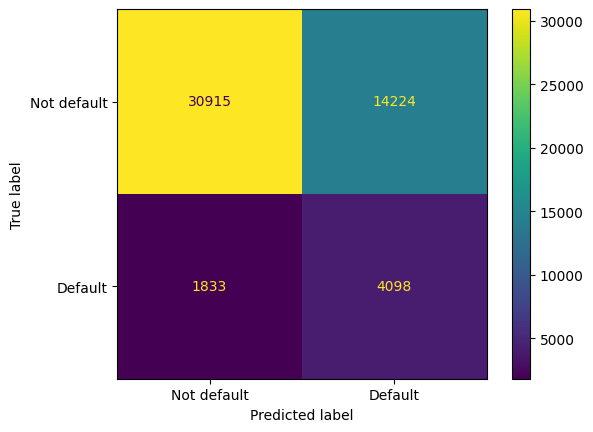

In [ ]:
cm=ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, display_labels=['Not default', 'Default'])

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dtree=DecisionTreeClassifier(criterion='gini', max_depth=7, random_state=42)
dtree.fit(x_smote, y_smote)

DecisionTreeClassifier(max_depth=7, random_state=42)

In [ ]:
y_predtrain_dtree=dtree.predict(x_smote)
y_predtest_dtree=dtree.predict(x_test_scaled)

In [ ]:
print("Train Accuracy:", round(accuracy_score(y_smote, y_predtrain_dtree),2))
print("Test Accuracy:", round(accuracy_score(y_test, y_predtest_dtree),2))

Train Accuracy: 0.72
Test Accuracy: 0.71


In [ ]:
report=classification_report(y_test, y_predtest_dtree)
print("Classification Report:\n\n", report)

Classification Report:

               precision    recall  f1-score   support

           0       0.92      0.74      0.82     45139
           1       0.21      0.52      0.30      5931

    accuracy                           0.71     51070
   macro avg       0.56      0.63      0.56     51070
weighted avg       0.84      0.71      0.76     51070



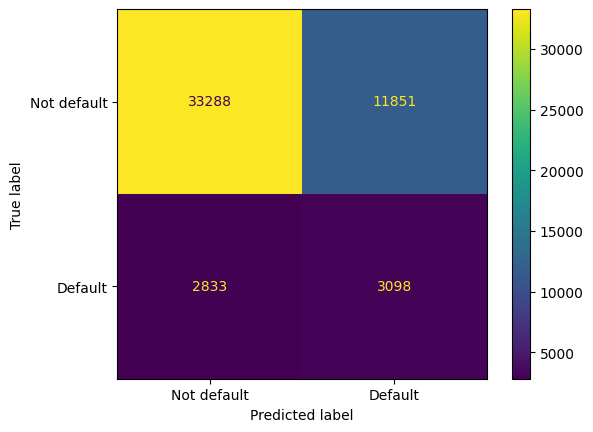

In [ ]:
cm=ConfusionMatrixDisplay.from_predictions(y_test, y_predtest_dtree, display_labels=['Not default', 'Default'])

In [ ]:
rf=RandomForestClassifier(n_estimators=60, max_depth=7, random_state=42)
rf.fit(x_smote, y_smote)


RandomForestClassifier(max_depth=7, n_estimators=60, random_state=42)

In [ ]:
y_predtrain_rf=rf.predict(x_smote)
y_predtest_rf=rf.predict(x_test_scaled)

In [ ]:
print("Train Accuracy:", round(accuracy_score(y_smote, y_predtrain_rf),2))
print("Test Accuracy:", round(accuracy_score(y_test, y_predtest_rf),2))

Train Accuracy: 0.78
Test Accuracy: 0.73


In [ ]:
report=classification_report(y_test, y_predtest_rf)
print("Classification Report:\n\n", report)

Classification Report:

               precision    recall  f1-score   support

           0       0.93      0.76      0.83     45139
           1       0.23      0.55      0.33      5931

    accuracy                           0.73     51070
   macro avg       0.58      0.65      0.58     51070
weighted avg       0.85      0.73      0.78     51070



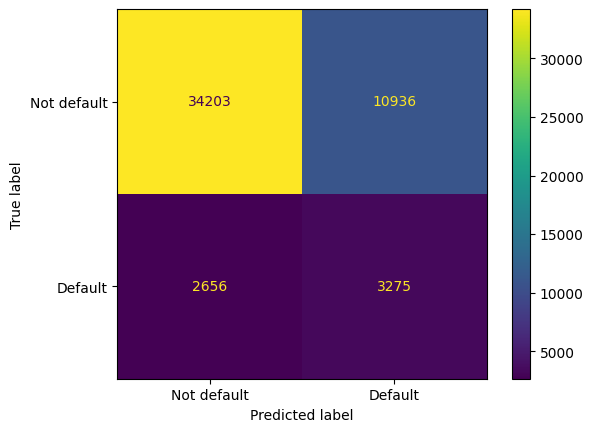

In [ ]:
cm=ConfusionMatrixDisplay.from_predictions(y_test, y_predtest_rf, display_labels=['Not default', 'Default'])

In [ ]:
xgb=XGBClassifier()
xgb.fit(x_smote, y_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_predtrain_xgb=xgb.predict(x_smote)
y_predtest_xgb=xgb.predict(x_test_scaled)

In [ ]:
print("Training Accuracy:", round(accuracy_score(y_smote, y_predtrain_xgb),2))
print("Test Accuracy:", round(accuracy_score(y_test, y_predtest_xgb),2))

Training Accuracy: 0.93
Test Accuracy: 0.88


In [ ]:
report=classification_report(y_test, y_predtest_xgb)
print("Classification Report:\n\n", report)

Classification Report:

               precision    recall  f1-score   support

           0       0.89      0.99      0.94     45139
           1       0.53      0.09      0.16      5931

    accuracy                           0.88     51070
   macro avg       0.71      0.54      0.55     51070
weighted avg       0.85      0.88      0.85     51070



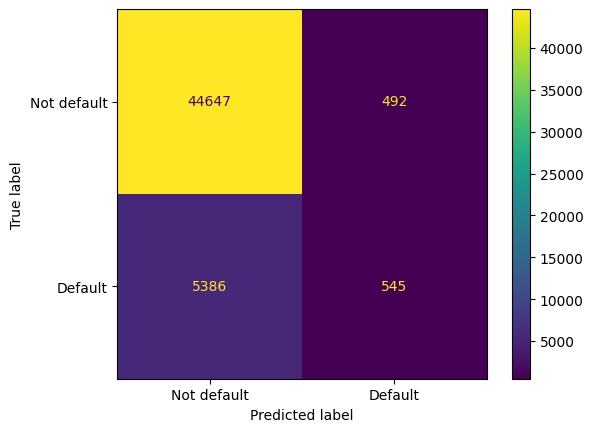

In [ ]:
cm=ConfusionMatrixDisplay.from_predictions(y_test, y_predtest_xgb, display_labels=['Not default', 'Default'])

In [ ]:
logistic_roc_auc = round(roc_auc_score(y_test, y_pred_test),2)
print(logistic_roc_auc)

0.69


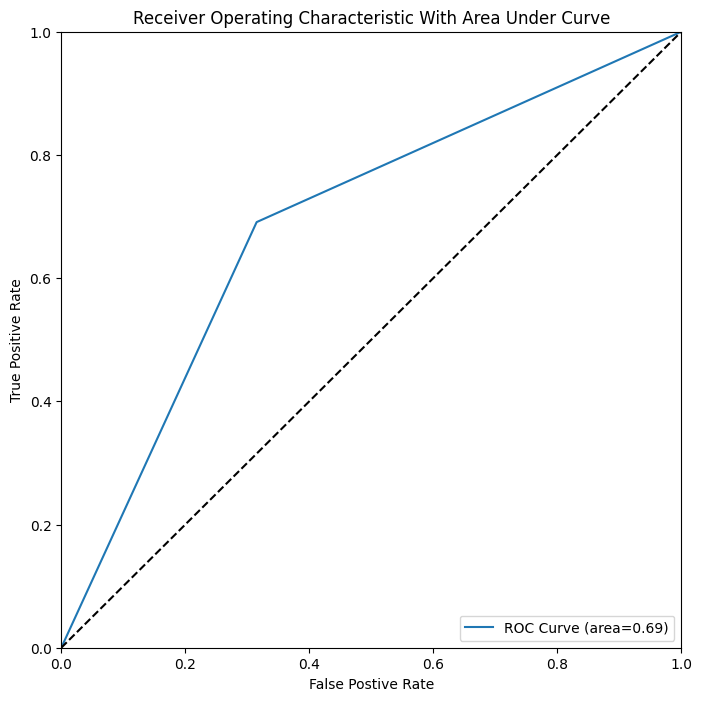

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_test)
plt.figure(figsize=(8,8))
plt.plot(fpr, tpr, label=f"ROC Curve (area={logistic_roc_auc:.2f})")
plt.plot([0,1], [0,1],'k--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.0])
plt.xlabel("False Postive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic With Area Under Curve")
plt.legend(loc="lower right")
plt.show()

In [ ]:
y_prob_logit = logit.predict_proba(x_test_scaled)[:,1]
logistic_roc_auc=round(roc_auc_score(y_test, y_prob_logit),2)
print(logistic_roc_auc)

0.75


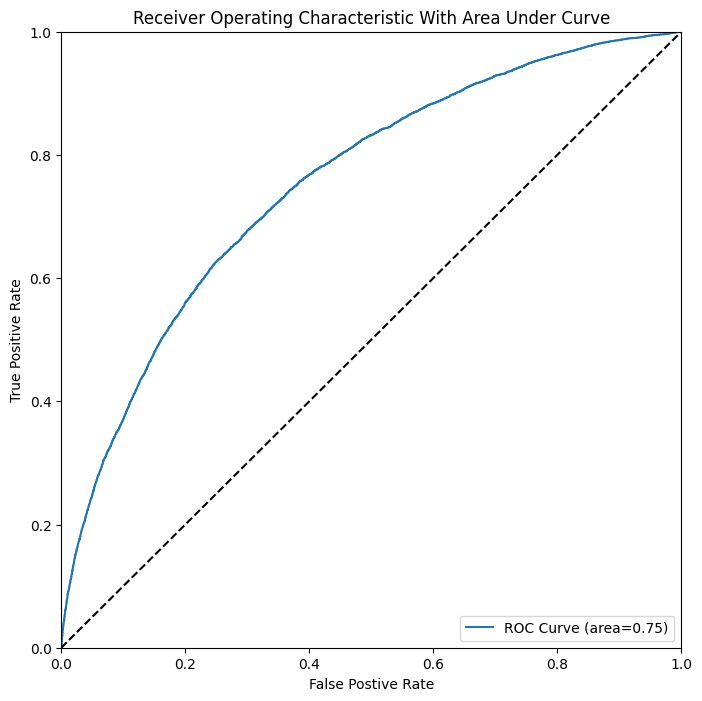

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_logit)
plt.figure(figsize=(8,8))
plt.plot(fpr, tpr, label=f"ROC Curve (area={logistic_roc_auc:.2f})")
plt.plot([0,1], [0,1],'k--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.0])
plt.xlabel("False Postive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic With Area Under Curve")
plt.legend(loc="lower right")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_test),
        accuracy_score(y_test, y_predtest_dtree),
        accuracy_score(y_test, y_predtest_rf),
        accuracy_score(y_test, y_predtest_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_test),
        precision_score(y_test, y_predtest_dtree),
        precision_score(y_test, y_predtest_rf),
        precision_score(y_test, y_predtest_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_test),
        recall_score(y_test, y_predtest_dtree),
        recall_score(y_test, y_predtest_rf),
        recall_score(y_test, y_predtest_xgb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_test),
        f1_score(y_test, y_predtest_dtree),
        f1_score(y_test, y_predtest_rf),
        f1_score(y_test, y_predtest_xgb)
    ]
})

results


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.685588,0.223666,0.690946,0.337938
1,Decision Tree,0.712473,0.207238,0.522340,0.296743
2,Random Forest,0.733855,0.230455,0.552183,0.325191
3,XGBoost,0.884903,0.525554,0.091890,0.156429


In [ ]:
imp = rf.feature_importances_

# Create dataframe
featNames = x_train_scaled_df.columns
featImp = pd.DataFrame({
    "Feature": featNames,
    "Importance": imp
})


In [ ]:
featImp = featImp.sort_values(by="Importance", ascending=False).reset_index(drop=True)

featImp


,Feature,Importance
0,Age,0.249294
1,NumCreditLines,0.135973
2,InterestRate,0.134897
3,LoanTerm,0.120528
4,MonthsEmployed,0.077494
5,LoanAmount,0.061203
6,Income,0.059537
7,HasCoSigner_Yes,0.045990
8,HasDependents_Yes,0.042650
9,HasMortgage_Yes,0.027454
